# Assignment 3 - Logistic Regression

In [24]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [25]:
feature_names = []

with open("spambase.names", "r") as file:
    for line in file:
        line = line.strip()
        if line != "" and not line.startswith("|"):
            match = re.match(r"([^:]+):\s+continuous\.", line)
            if match:
                feature_names.append(match.group(1))

column_names = feature_names + ["spam"]
data = pd.read_csv("spambase.data", header=None, names=column_names)

print("Data shape:", data.shape)
print("First 5 rows:")
print(data.head())

Data shape: (4601, 58)
First 5 rows:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_;  char_freq_(  \
0             0.00            0.00

In [26]:
X = data[feature_names]
y = data["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (3450, 57)
Testing set shape: (1151, 57)


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training finished.")

Model training finished.


In [28]:
probabilities = model.predict_proba(X_test_scaled)[:, 1]
predictions = (probabilities >= 0.5).astype(int)

cm = confusion_matrix(y_test, predictions)
accuracy = accuracy_score(y_test, predictions)
error = 1 - accuracy
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("Question 1")
print()
print("Confusion Matrix:")
print(cm)
print()
print("Accuracy:", accuracy)
print("Error:", error)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Question 1

Confusion Matrix:
[[667  30]
 [ 53 401]]

Accuracy: 0.9278887923544744
Error: 0.07211120764552559
Precision: 0.9303944315545244
Recall: 0.8832599118942731
F1 Score: 0.9062146892655367


In [29]:
coefficients = model.coef_[0]

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_table = coef_table.sort_values("Coefficient", ascending=False)

print("Question 2")
print()
print("Top 10 positive coefficients:")
print(coef_table.head(10).to_string(index=False))
print()
print("Top 10 negative coefficients:")
print(coef_table.tail(10).sort_values("Coefficient").to_string(index=False))
print()
print("All coefficients:")
print(coef_table.to_string(index=False))

Question 2

Top 10 positive coefficients:
                   Feature  Coefficient
capital_run_length_longest     1.719832
               char_freq_$     1.366262
capital_run_length_average     1.185180
               char_freq_#     0.988575
              word_freq_3d     0.867262
          word_freq_remove     0.831901
             word_freq_000     0.793984
            word_freq_free     0.753701
        word_freq_business     0.406168
             word_freq_our     0.389064

Top 10 negative coefficients:
          Feature  Coefficient
 word_freq_george    -3.899146
     word_freq_hp    -2.294340
     word_freq_85    -1.692253
     word_freq_cs    -1.621543
word_freq_meeting    -1.547263
    word_freq_edu    -1.520577
    word_freq_415    -1.421432
    word_freq_lab    -1.379871
    word_freq_hpl    -1.059961
     word_freq_re    -0.850953

All coefficients:
                   Feature  Coefficient
capital_run_length_longest     1.719832
               char_freq_$     1.366262
capital

In [30]:
threshold_list = [0.25, 0.5, 0.75, 0.9]
results = []

for threshold in threshold_list:
    threshold_predictions = (probabilities >= threshold).astype(int)

    accuracy_value = accuracy_score(y_test, threshold_predictions)
    precision_value = precision_score(y_test, threshold_predictions, zero_division=0)
    recall_value = recall_score(y_test, threshold_predictions, zero_division=0)

    results.append([threshold, accuracy_value, precision_value, recall_value])

threshold_table = pd.DataFrame(
    results,
    columns=["Threshold", "Accuracy", "Precision", "Recall"]
)

print("Question 3")
print()
print(threshold_table.to_string(index=False))

Question 3

 Threshold  Accuracy  Precision   Recall
      0.25  0.907906   0.834615 0.955947
      0.50  0.927889   0.930394 0.883260
      0.75  0.897480   0.956522 0.775330
      0.90  0.847089   0.989437 0.618943


## Problem 2 - Gradient Descent for Logistic Regression

In [31]:
import numpy as np

y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

X_train_gd = np.column_stack((np.ones(X_train_scaled.shape[0]), X_train_scaled))
X_test_gd = np.column_stack((np.ones(X_test_scaled.shape[0]), X_test_scaled))

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def cross_entropy_loss(y_true, y_prob):
    y_prob = np.clip(y_prob, 1e-15, 1 - 1e-15)
    loss = -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
    return loss

def run_gradient_descent(X, y, learning_rate, iterations):
    weights = np.zeros(X.shape[1])
    saved_losses = {}

    for iteration in range(1, iterations + 1):
        predictions = sigmoid(X @ weights)
        gradient = (X.T @ (predictions - y)) / len(y)
        weights = weights - learning_rate * gradient

        if iteration in [10, 50, 100]:
            loss = cross_entropy_loss(y, sigmoid(X @ weights))
            saved_losses[iteration] = loss

    return weights, saved_losses

def get_metrics(X, y, weights):
    probabilities = sigmoid(X @ weights)
    predictions = (probabilities >= 0.5).astype(int)

    accuracy_value = accuracy_score(y, predictions)
    precision_value = precision_score(y, predictions, zero_division=0)
    recall_value = recall_score(y, predictions, zero_division=0)
    f1_value = f1_score(y, predictions, zero_division=0)

    return accuracy_value, precision_value, recall_value, f1_value

In [32]:
learning_rates = [0.01, 0.1, 1.0]

loss_results = []
metric_results = []

for learning_rate in learning_rates:
    weights, saved_losses = run_gradient_descent(X_train_gd, y_train_array, learning_rate, 100)

    train_accuracy, train_precision, train_recall, train_f1 = get_metrics(X_train_gd, y_train_array, weights)
    test_accuracy, test_precision, test_recall, test_f1 = get_metrics(X_test_gd, y_test_array, weights)

    loss_results.append([
        learning_rate,
        saved_losses[10],
        saved_losses[50],
        saved_losses[100]
    ])

    metric_results.append([
        learning_rate,
        "Train",
        train_accuracy,
        train_precision,
        train_recall,
        train_f1
    ])

    metric_results.append([
        learning_rate,
        "Test",
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ])

loss_table = pd.DataFrame(
    loss_results,
    columns=["Learning Rate", "Loss at 10", "Loss at 50", "Loss at 100"]
)

metric_table = pd.DataFrame(
    metric_results,
    columns=["Learning Rate", "Data", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print("Problem 2")
print()
print("Cross-entropy loss after 10, 50, and 100 iterations:")
print(loss_table.to_string(index=False))
print()
print("Metrics at 100 iterations:")
print(metric_table.to_string(index=False))

Problem 2

Cross-entropy loss after 10, 50, and 100 iterations:
 Learning Rate  Loss at 10  Loss at 50  Loss at 100
          0.01    0.651338    0.542090     0.469330
          0.10    0.465983    0.325163     0.289826
          1.00    0.285940    0.243037     0.230871

Metrics at 100 iterations:
 Learning Rate  Data  Accuracy  Precision   Recall  F1 Score
          0.01 Train  0.900290   0.883598 0.860191  0.871738
          0.01  Test  0.896612   0.873051 0.863436  0.868217
          0.10 Train  0.910725   0.915415 0.852097  0.882622
          0.10  Test  0.903562   0.905437 0.843612  0.873432
          1.00 Train  0.922029   0.925117 0.872701  0.898145
          1.00  Test  0.921807   0.925234 0.872247  0.897959


In [33]:
package_results = []

package_train_predictions = model.predict(X_train_scaled)
package_test_predictions = model.predict(X_test_scaled)

package_results.append([
    "Train",
    accuracy_score(y_train, package_train_predictions),
    precision_score(y_train, package_train_predictions, zero_division=0),
    recall_score(y_train, package_train_predictions, zero_division=0),
    f1_score(y_train, package_train_predictions, zero_division=0)
])

package_results.append([
    "Test",
    accuracy_score(y_test, package_test_predictions),
    precision_score(y_test, package_test_predictions, zero_division=0),
    recall_score(y_test, package_test_predictions, zero_division=0),
    f1_score(y_test, package_test_predictions, zero_division=0)
])

package_table = pd.DataFrame(
    package_results,
    columns=["Data", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print("Package logistic regression metrics:")
print(package_table.to_string(index=False))

Package logistic regression metrics:
 Data  Accuracy  Precision   Recall  F1 Score
Train  0.928986   0.927803 0.888889  0.907929
 Test  0.927889   0.930394 0.883260  0.906215


## Problem 3 - Comparing classifiers

In [34]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score

os.environ["LOKY_MAX_CPU_COUNT"] = "1"
warnings.filterwarnings("ignore")

In [35]:
k_values = [1, 3, 5, 7, 9, 11, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for k in k_values:
    accuracy_list = []
    error_list = []
    precision_list = []
    recall_list = []

    for train_index, val_index in cv.split(X_train_scaled, y_train):
        X_fold_train = X_train_scaled[train_index]
        X_fold_val = X_train_scaled[val_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_val = y_train.iloc[val_index]

        knn_model = KNeighborsClassifier(n_neighbors=k)
        knn_model.fit(X_fold_train, y_fold_train)
        val_predictions = knn_model.predict(X_fold_val)

        accuracy_value = accuracy_score(y_fold_val, val_predictions)
        error_value = 1 - accuracy_value
        precision_value = precision_score(y_fold_val, val_predictions, zero_division=0)
        recall_value = recall_score(y_fold_val, val_predictions, zero_division=0)

        accuracy_list.append(accuracy_value)
        error_list.append(error_value)
        precision_list.append(precision_value)
        recall_list.append(recall_value)

    cv_results.append([
        k,
        np.mean(accuracy_list),
        np.mean(error_list),
        np.mean(precision_list),
        np.mean(recall_list)
    ])

cv_table = pd.DataFrame(
    cv_results,
    columns=["k", "Accuracy", "Error", "Precision", "Recall"]
)

best_k = int(cv_table.loc[cv_table["Error"].idxmin(), "k"])

print("Problem 3")
print()
print("Cross-validation results for kNN:")
print(cv_table.to_string(index=False))
print()
print("Best k:", best_k)

Problem 3

Cross-validation results for kNN:
 k  Accuracy    Error  Precision   Recall
 1  0.906087 0.093913   0.882413 0.878590
 3  0.905797 0.094203   0.884013 0.875635
 5  0.906667 0.093333   0.897339 0.861664
 7  0.905797 0.094203   0.898437 0.857977
 9  0.907536 0.092464   0.903768 0.856509
11  0.900580 0.099420   0.897762 0.844006
15  0.896522 0.103478   0.901036 0.828557

Best k: 9


In [36]:
logistic_model_p3 = LogisticRegression(max_iter=5000, random_state=42)
lda_model = LinearDiscriminantAnalysis()
knn_model = KNeighborsClassifier(n_neighbors=best_k)

models = {
    "Logistic Regression": logistic_model_p3,
    "LDA": lda_model,
    "kNN": knn_model
}

model_results = []

for model_name, current_model in models.items():
    current_model.fit(X_train_scaled, y_train)

    train_predictions = current_model.predict(X_train_scaled)
    test_predictions = current_model.predict(X_test_scaled)

    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)

    model_results.append([
        model_name,
        "Train",
        train_accuracy,
        1 - train_accuracy,
        precision_score(y_train, train_predictions, zero_division=0),
        recall_score(y_train, train_predictions, zero_division=0)
    ])

    model_results.append([
        model_name,
        "Test",
        test_accuracy,
        1 - test_accuracy,
        precision_score(y_test, test_predictions, zero_division=0),
        recall_score(y_test, test_predictions, zero_division=0)
    ])

model_table = pd.DataFrame(
    model_results,
    columns=["Model", "Data", "Accuracy", "Error", "Precision", "Recall"]
)

test_only = model_table[model_table["Data"] == "Test"].copy()
best_model = test_only.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
worst_model = test_only.sort_values("Accuracy", ascending=True).iloc[0]["Model"]

print("Metrics for all 3 classifiers:")
print(model_table.to_string(index=False))
print()
print("Best model on test accuracy:", best_model)
print("Worst model on test accuracy:", worst_model)
print()
print("Observation: logistic regression and kNN perform better than LDA on this split.")
print("Observation: logistic regression has the highest test accuracy here.")

Metrics for all 3 classifiers:
              Model  Data  Accuracy    Error  Precision   Recall
Logistic Regression Train  0.928986 0.071014   0.927803 0.888889
Logistic Regression  Test  0.927889 0.072111   0.930394 0.883260
                LDA Train  0.891014 0.108986   0.918298 0.793966
                LDA  Test  0.884448 0.115552   0.910486 0.784141
                kNN Train  0.920290 0.079710   0.918856 0.874908
                kNN  Test  0.906169 0.093831   0.893182 0.865639

Best model on test accuracy: Logistic Regression
Worst model on test accuracy: LDA

Observation: logistic regression and kNN perform better than LDA on this split.
Observation: logistic regression has the highest test accuracy here.


AUC for logistic regression on the test set: 0.9727529563453189


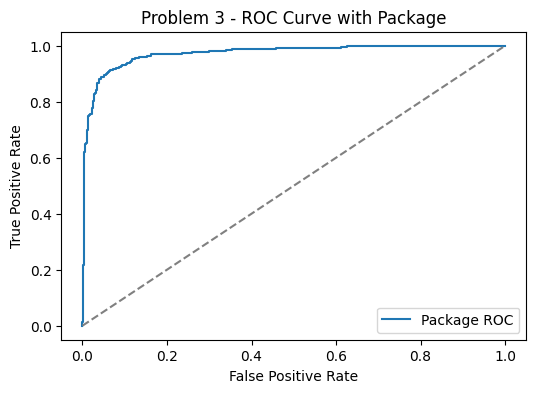

In [37]:
logistic_model_p3.fit(X_train_scaled, y_train)
test_probabilities = logistic_model_p3.predict_proba(X_test_scaled)[:, 1]

fpr_package, tpr_package, threshold_package = roc_curve(y_test, test_probabilities)
auc_value = roc_auc_score(y_test, test_probabilities)

print("AUC for logistic regression on the test set:", auc_value)

plt.figure(figsize=(6, 4))
plt.plot(fpr_package, tpr_package, label="Package ROC")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Problem 3 - ROC Curve with Package")
plt.legend()
plt.show()

Manual ROC points:
 Threshold  False Positive Rate  True Positive Rate
       0.0             1.000000            1.000000
       0.1             0.307030            0.980176
       0.2             0.167862            0.969163
       0.3             0.098996            0.931718
       0.4             0.065997            0.909692
       0.5             0.043042            0.883260
       0.6             0.034433            0.850220
       0.7             0.027260            0.806167
       0.8             0.015782            0.748899
       0.9             0.004304            0.618943
       1.0             0.000000            0.000000

Difference: the manual ROC uses only a few threshold points, so it looks less smooth.
To make them more similar, use many more threshold values.


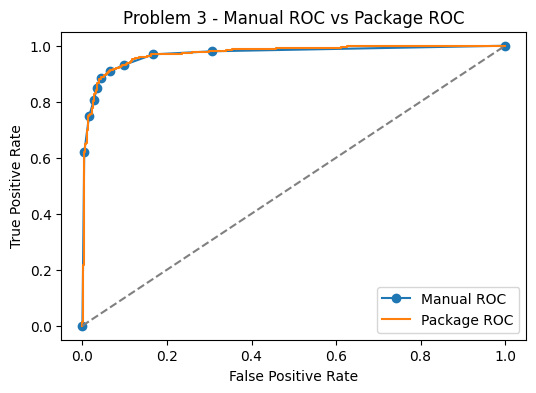

In [38]:
manual_results = []
threshold_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
y_test_array = y_test.to_numpy()

for threshold in threshold_values:
    manual_predictions = (test_probabilities >= threshold).astype(int)

    tp = ((manual_predictions == 1) & (y_test_array == 1)).sum()
    fp = ((manual_predictions == 1) & (y_test_array == 0)).sum()
    tn = ((manual_predictions == 0) & (y_test_array == 0)).sum()
    fn = ((manual_predictions == 0) & (y_test_array == 1)).sum()

    if tp + fn == 0:
        tpr_value = 0
    else:
        tpr_value = tp / (tp + fn)

    if fp + tn == 0:
        fpr_value = 0
    else:
        fpr_value = fp / (fp + tn)

    manual_results.append([threshold, fpr_value, tpr_value])

manual_table = pd.DataFrame(
    manual_results,
    columns=["Threshold", "False Positive Rate", "True Positive Rate"]
)

print("Manual ROC points:")
print(manual_table.to_string(index=False))
print()
print("Difference: the manual ROC uses only a few threshold points, so it looks less smooth.")
print("To make them more similar, use many more threshold values.")

plt.figure(figsize=(6, 4))
plt.plot(manual_table["False Positive Rate"], manual_table["True Positive Rate"], marker="o", label="Manual ROC")
plt.plot(fpr_package, tpr_package, label="Package ROC")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Problem 3 - Manual ROC vs Package ROC")
plt.legend()
plt.show()

## Problem 4 - Cross validation

In [39]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

X_full = data[feature_names].to_numpy()
y_full = data["spam"].to_numpy()

random_generator = np.random.default_rng(42)
shuffled_indices = np.arange(len(X_full))
random_generator.shuffle(shuffled_indices)

X_full = X_full[shuffled_indices]
y_full = y_full[shuffled_indices]

def make_folds(number_of_rows, k):
    index_numbers = np.arange(number_of_rows)
    folds = np.array_split(index_numbers, k)
    return folds

def run_manual_kfold_cv(model_name, X, y, k):
    folds = make_folds(len(X), k)
    fold_errors = []

    for fold_number in range(k):
        validation_indices = folds[fold_number]
        training_parts = []

        for i in range(k):
            if i != fold_number:
                training_parts.append(folds[i])

        training_indices = np.concatenate(training_parts)

        X_train_fold = X[training_indices]
        X_validation_fold = X[validation_indices]
        y_train_fold = y[training_indices]
        y_validation_fold = y[validation_indices]

        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_validation_fold = scaler.transform(X_validation_fold)

        if model_name == "Logistic Regression":
            model = LogisticRegression(max_iter=5000, random_state=42)
        else:
            model = LinearDiscriminantAnalysis()

        model.fit(X_train_fold, y_train_fold)
        validation_predictions = model.predict(X_validation_fold)

        accuracy_value = accuracy_score(y_validation_fold, validation_predictions)
        error_value = 1 - accuracy_value
        fold_errors.append(error_value)

    average_error = np.mean(fold_errors)
    return fold_errors, average_error

In [40]:
problem4_results = []

for model_name in ["Logistic Regression", "LDA"]:
    for k_value in [5, 10]:
        fold_errors, average_error = run_manual_kfold_cv(model_name, X_full, y_full, k_value)

        print(model_name, "- k =", k_value)
        print("Fold validation errors:")

        for fold_number, error_value in enumerate(fold_errors, start=1):
            print("Fold", fold_number, ":", error_value)

        print("Average validation error:", average_error)
        print()

        problem4_results.append([model_name, k_value, average_error])

problem4_table = pd.DataFrame(
    problem4_results,
    columns=["Model", "k", "Average Validation Error"]
)

print("Problem 4 summary table:")
print(problem4_table.to_string(index=False))
print()

best_row = problem4_table.sort_values("Average Validation Error").iloc[0]
worst_row = problem4_table.sort_values("Average Validation Error").iloc[-1]

print("Best result:", best_row["Model"], "with k =", int(best_row["k"]))
print("Worst result:", worst_row["Model"], "with k =", int(worst_row["k"]))
print()
print("Comparison:")
print("Logistic Regression performs better than LDA because it has lower average validation error for both k = 5 and k = 10.")

Logistic Regression - k = 5
Fold validation errors:
Fold 1 : 0.0684039087947883
Fold 2 : 0.06739130434782614
Fold 3 : 0.07499999999999996
Fold 4 : 0.0902173913043478
Fold 5 : 0.08260869565217388
Average validation error: 0.07672426001982721

Logistic Regression - k = 10
Fold validation errors:
Fold 1 : 0.0585683297180043
Fold 2 : 0.07826086956521738
Fold 3 : 0.04347826086956519
Fold 4 : 0.07608695652173914
Fold 5 : 0.060869565217391286
Fold 6 : 0.09347826086956523
Fold 7 : 0.10434782608695647
Fold 8 : 0.06304347826086953
Fold 9 : 0.07173913043478264
Fold 10 : 0.08695652173913049
Average validation error: 0.07368291992832217

LDA - k = 5
Fold validation errors:
Fold 1 : 0.09771986970684043
Fold 2 : 0.10543478260869565
Fold 3 : 0.116304347826087
Fold 4 : 0.13043478260869568
Fold 5 : 0.11521739130434783
Average validation error: 0.11302223481093332

LDA - k = 10
Fold validation errors:
Fold 1 : 0.09327548806941433
Fold 2 : 0.11304347826086958
Fold 3 : 0.09130434782608698
Fold 4 : 0.119565